# What GitHub's most-starred ML repositories say about open-source AI in 2026

A snapshot of every machine learning and AI repository on GitHub with 500+ stars across 20 topics, pulled from GitHub's public API. Four questions:

1. **Concentration:** how unequal is attention?
2. **Shift:** what is being built now versus five years ago?
3. **Upkeep:** how many popular repos are still maintained?
4. **Licensing:** what can you actually build on?

Every number below is computed from the data in the cell that prints it.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')


def find_csv(name='github_ml_repos.csv'):
    # Kaggle mounts inputs at a depth that has changed over time; walk for it.
    for root, _, files in os.walk('/kaggle/input'):
        if name in files:
            return Path(root) / name
    return Path(name)


df = pd.read_csv(find_csv(), parse_dates=['created_at', 'pushed_at'])
df['created_year'] = df['created_at'].dt.year
df['topics'] = df['topics'].fillna('')
df['matched_topics'] = df['matched_topics'].fillna('')
print(f'{len(df):,} repositories, {df.stars.sum():,} stars, snapshot taken '
      f"{(df.pushed_at.max()).date()}")
df.head()

7,550 repositories, 37,010,704 stars, snapshot taken 2026-10-01


,repo,owner,owner_type,description,language,stars,forks,open_issues,size_kb,license,...,n_topics,matched_topics,created_at,pushed_at,age_days,days_since_push,archived,is_fork,has_homepage,created_year
0,affaan-m/ECC,affaan-m,User,The agent harness performance optimization sys...,JavaScript,270541,40449,241,54255,MIT,...,8,ai-agents|llm,2026-01-18 00:51:51+00:00,2026-09-30 18:45:04+00:00,256,0,False,False,True,2026
1,NousResearch/hermes-agent,NousResearch,Organization,The agent that grows with you,Python,250546,53599,48034,1119035,MIT,...,13,ai-agents|llm,2025-07-22 22:22:28+00:00,2026-10-01 17:08:04+00:00,435,-1,False,False,True,2025
2,deepseek-ai/deepseek-harness,deepseek-ai,Organization,DeepSeek Harness: Everything is a Plugin.,TypeScript,241623,29015,0,255632,MIT,...,4,ai-agents,2026-08-13 11:56:32+00:00,2026-09-29 09:41:57+00:00,49,2,False,False,True,2026
3,tensorflow/tensorflow,tensorflow,Organization,An Open Source Machine Learning Framework for ...,C++,200650,77992,3229,1393001,Apache-2.0,...,8,deep-learning|machine-learning|neural-network|...,2015-11-07 01:19:20+00:00,2026-10-01 17:00:57+00:00,3981,-1,False,False,True,2015
4,Significant-Gravitas/AutoGPT,Significant-Gravitas,Organization,AutoGPT is the vision of accessible AI for eve...,Python,187634,45977,603,692716,NaN,...,11,artificial-intelligence|llm,2023-03-16 09:21:07+00:00,2026-10-01 17:01:34+00:00,1295,-1,False,False,True,2023


## 1. Concentration: a few repositories hold most of the attention

Top 1% of repos hold 21% of stars; top 10% hold 61%.
Gini coefficient of stars: 0.69


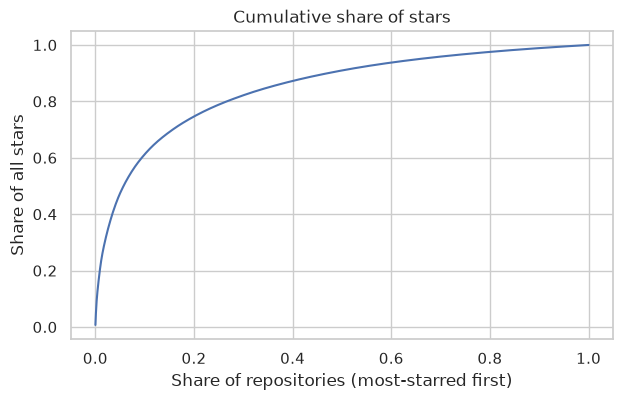

In [2]:
stars = np.sort(df['stars'].to_numpy())[::-1]
share = stars.cumsum() / stars.sum()
top1 = share[int(len(stars) * 0.01) - 1]
top10 = share[int(len(stars) * 0.10) - 1]
trapezoid = getattr(np, 'trapezoid', None) or np.trapz  # renamed in numpy 2
gini = 1 - 2 * trapezoid(np.sort(stars).cumsum() / stars.sum(), dx=1 / len(stars))
print(f'Top 1% of repos hold {top1:.0%} of stars; top 10% hold {top10:.0%}.')
print(f'Gini coefficient of stars: {gini:.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(stars) + 1) / len(stars), share)
ax.set(xlabel='Share of repositories (most-starred first)', ylabel='Share of all stars',
       title='Cumulative share of stars')
plt.show()

## 2. Shift: what gets built each year

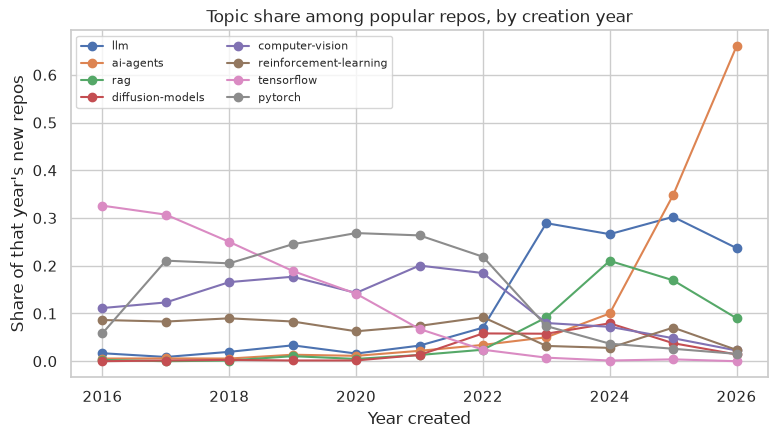

,llm,ai-agents,rag,diffusion-models,computer-vision,reinforcement-learning,tensorflow,pytorch
created_year,,,,,,,,
2023,0.29,0.05,0.09,0.06,0.08,0.03,0.01,0.07
2024,0.27,0.10,0.21,0.08,0.07,0.03,0.00,0.04
2025,0.30,0.35,0.17,0.04,0.05,0.07,0.00,0.03
2026,0.24,0.66,0.09,0.01,0.02,0.02,0.00,0.02


In [3]:
focus = ['llm', 'ai-agents', 'rag', 'diffusion-models', 'computer-vision',
         'reinforcement-learning', 'tensorflow', 'pytorch']
recent = df[df.created_year.between(2016, df.created_year.max())]
by_year = pd.DataFrame({
    t: recent[recent.matched_topics.str.split('|').map(lambda ts, t=t: t in ts)]
        .groupby('created_year').size()
    for t in focus
}).fillna(0)
share_by_year = by_year.div(recent.groupby('created_year').size(), axis=0)
ax = share_by_year.plot(figsize=(9, 4.5), marker='o')
ax.set(ylabel='Share of that year\'s new repos', xlabel='Year created',
       title='Topic share among popular repos, by creation year')
ax.legend(ncol=2, fontsize=8)
plt.show()
share_by_year.round(2).tail(4)

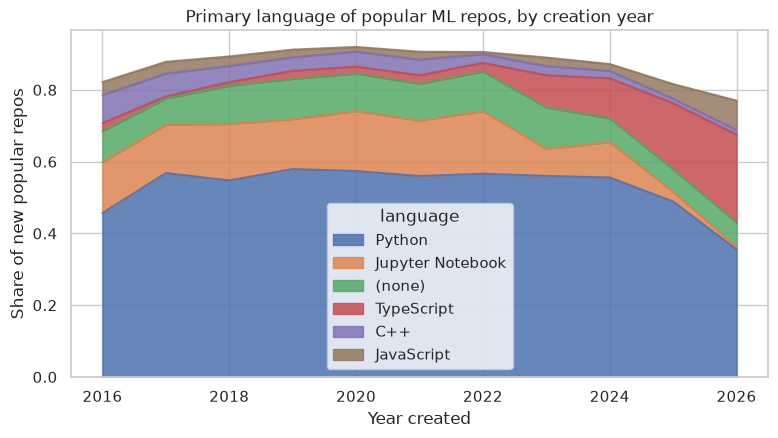

language,Python,Jupyter Notebook,(none),TypeScript,C++,JavaScript
created_year,,,,,,
2023,0.56,0.08,0.12,0.09,0.03,0.02
2024,0.56,0.10,0.07,0.11,0.02,0.02
2025,0.49,0.03,0.06,0.18,0.01,0.04
2026,0.36,0.01,0.07,0.25,0.01,0.08


In [4]:
langs = (recent.assign(language=recent.language.fillna('(none)'))
        .pivot_table(index='created_year', columns='language', values='repo',
                     aggfunc='count', fill_value=0))
top_langs = langs.sum().nlargest(6).index
lang_share = langs[top_langs].div(langs.sum(axis=1), axis=0)
ax = lang_share.plot.area(figsize=(9, 4.5), alpha=0.85)
ax.set(ylabel='Share of new popular repos', xlabel='Year created',
       title='Primary language of popular ML repos, by creation year')
plt.show()
lang_share.round(2).tail(4)

## 3. Upkeep: how many popular repos are still maintained?

In [5]:
df['stale'] = df['days_since_push'] > 365
per_topic = (df.assign(topic=df.matched_topics.str.split('|')).explode('topic')
             .groupby('topic').agg(repos=('repo', 'size'),
                                   stale=('stale', 'mean'),
                                   archived=('archived', 'mean'),
                                   median_stars=('stars', 'median'))
             .sort_values('stale'))
print(f"Overall: {df.stale.mean():.0%} not pushed to in a year, {df.archived.mean():.0%} archived.")
per_topic.style.format({'stale': '{:.0%}', 'archived': '{:.0%}', 'median_stars': '{:,.0f}'})

Overall: 43% not pushed to in a year, 5% archived.


,repos,stale,archived,median_stars
topic,,,,
ai-agents,1000,2%,1%,"1,362"
llm,1000,13%,3%,"4,256"
rag,467,13%,4%,"1,696"
generative-ai,320,18%,3%,"1,378"
mlops,152,30%,7%,"2,464"
large-language-models,442,36%,4%,"1,196"
time-series,184,40%,5%,"1,188"
speech-recognition,196,42%,5%,"1,144"
machine-learning,1000,42%,6%,"4,290"


## 4. Licensing: what can you build on?

In [6]:
permissive = {'MIT', 'Apache-2.0', 'BSD-3-Clause', 'BSD-2-Clause', 'ISC', 'Unlicense', 'CC0-1.0'}
copyleft = {'GPL-3.0', 'GPL-2.0', 'AGPL-3.0', 'LGPL-3.0', 'LGPL-2.1', 'MPL-2.0'}

def family(spdx):
    if not isinstance(spdx, str) or not spdx:
        return 'none / unclear'
    return 'permissive' if spdx in permissive else 'copyleft' if spdx in copyleft else 'other'

df['license_family'] = df['license'].map(family)
counts = df['license_family'].value_counts(normalize=True)
print(counts.map('{:.0%}'.format).to_string())
print(f"\nOf the 100 most-starred, {df.nlargest(100, 'stars').license_family.eq('none / unclear').sum()} "
      'have no clear license.')

license_family
permissive        70%
none / unclear    23%
copyleft           6%
other              1%

Of the 100 most-starred, 19 have no clear license.


## Using this dataset

- `matched_topics` records which of the 20 searched topics found a repo; `topics` is the repo's full topic list.
- GitHub search returns at most 1,000 results per query, so the very largest topics are truncated at their 1,000 most-starred repos. Treat per-topic counts as lower bounds.
- `days_since_push` and `age_days` are relative to the snapshot date.

Ideas: predict stars from early signals, cluster repos by topic sets, or compare this snapshot against a future one to measure growth.